# Seasonal Decomposition Plot – Python Code
✔ Works for both daily and monthly datasets

✔ Automatically handles missing values

✔ Includes additive & multiplicative decomposition

✔ Beautiful Matplotlib styling

## Basic Seasonal Decomposition (Additive)

C:\Users\NIL\AppData\Local\Temp\ipykernel_15596\642263882.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2020-01-01', periods=48, freq='M')


<Figure size 1200x800 with 0 Axes>

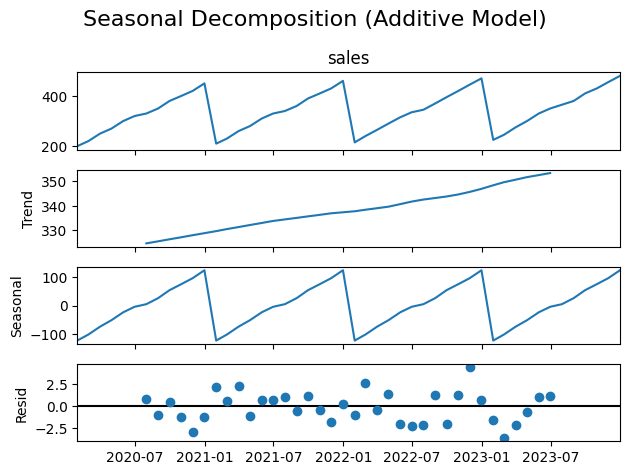

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# -------------------------
# SAMPLE DATA (Monthly)
# -------------------------
# If you have your own DataFrame, replace this with your dataset.
dates = pd.date_range(start='2020-01-01', periods=48, freq='M')
sales = [200,220,250,270,300,320,330,350,380,400,420,450,
         210,230,260,280,310,330,340,360,390,410,430,460,
         215,240,265,290,315,335,345,370,395,420,445,470,
         225,245,275,300,330,350,365,380,410,430,455,480]

df = pd.DataFrame({"sales": sales}, index=dates)

# -------------------------
# DECOMPOSITION
# -------------------------
result = seasonal_decompose(df['sales'], model='additive', period=12)

# -------------------------
# PLOT
# -------------------------
plt.figure(figsize=(12, 8))
result.plot()
plt.suptitle("Seasonal Decomposition (Additive Model)", fontsize=16)
plt.tight_layout()
plt.show()


## Multiplicative Seasonal Decomposition

Use this when your data shows proportional seasonal effect (e.g., high sales = bigger seasonal swing).

<Figure size 1200x800 with 0 Axes>

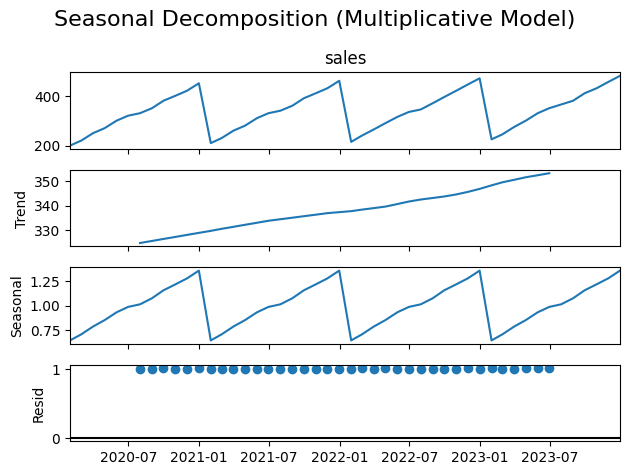

In [2]:
result = seasonal_decompose(df['sales'], model='multiplicative', period=12)

plt.figure(figsize=(12, 8))
result.plot()
plt.suptitle("Seasonal Decomposition (Multiplicative Model)", fontsize=16)
plt.tight_layout()
plt.show()


## Seasonal Decomposition on Real Dataset (Daily Data)

If your dataset is daily (e.g., stock prices, website traffic), use:

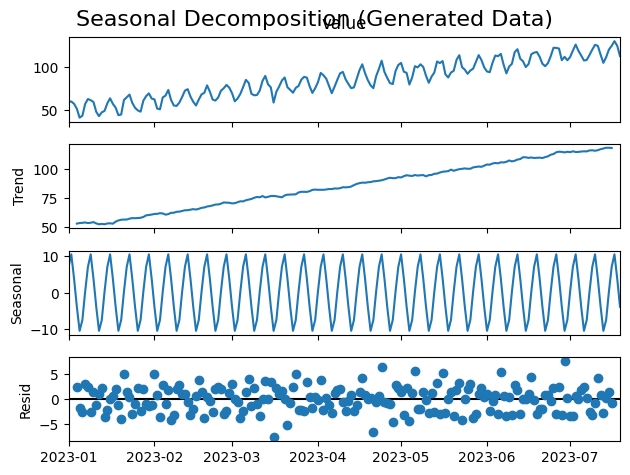

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# ------------------------------
# Generate daily sample data
# ------------------------------
np.random.seed(42)
dates = pd.date_range(start="2023-01-01", periods=200, freq="D")

trend = np.linspace(50, 120, 200)
seasonal = 10 * np.sin(2 * np.pi * dates.dayofyear / 7)   # weekly pattern
noise = np.random.normal(0, 3, 200)

values = trend + seasonal + noise

df = pd.DataFrame({"value": values}, index=dates)

# ------------------------------
# Seasonal Decomposition
# ------------------------------
result = seasonal_decompose(df['value'], model='additive', period=7)

result.plot()
plt.suptitle("Seasonal Decomposition (Generated Data)", fontsize=16)
plt.show()


## Customizing the Plot (Improved Styling)

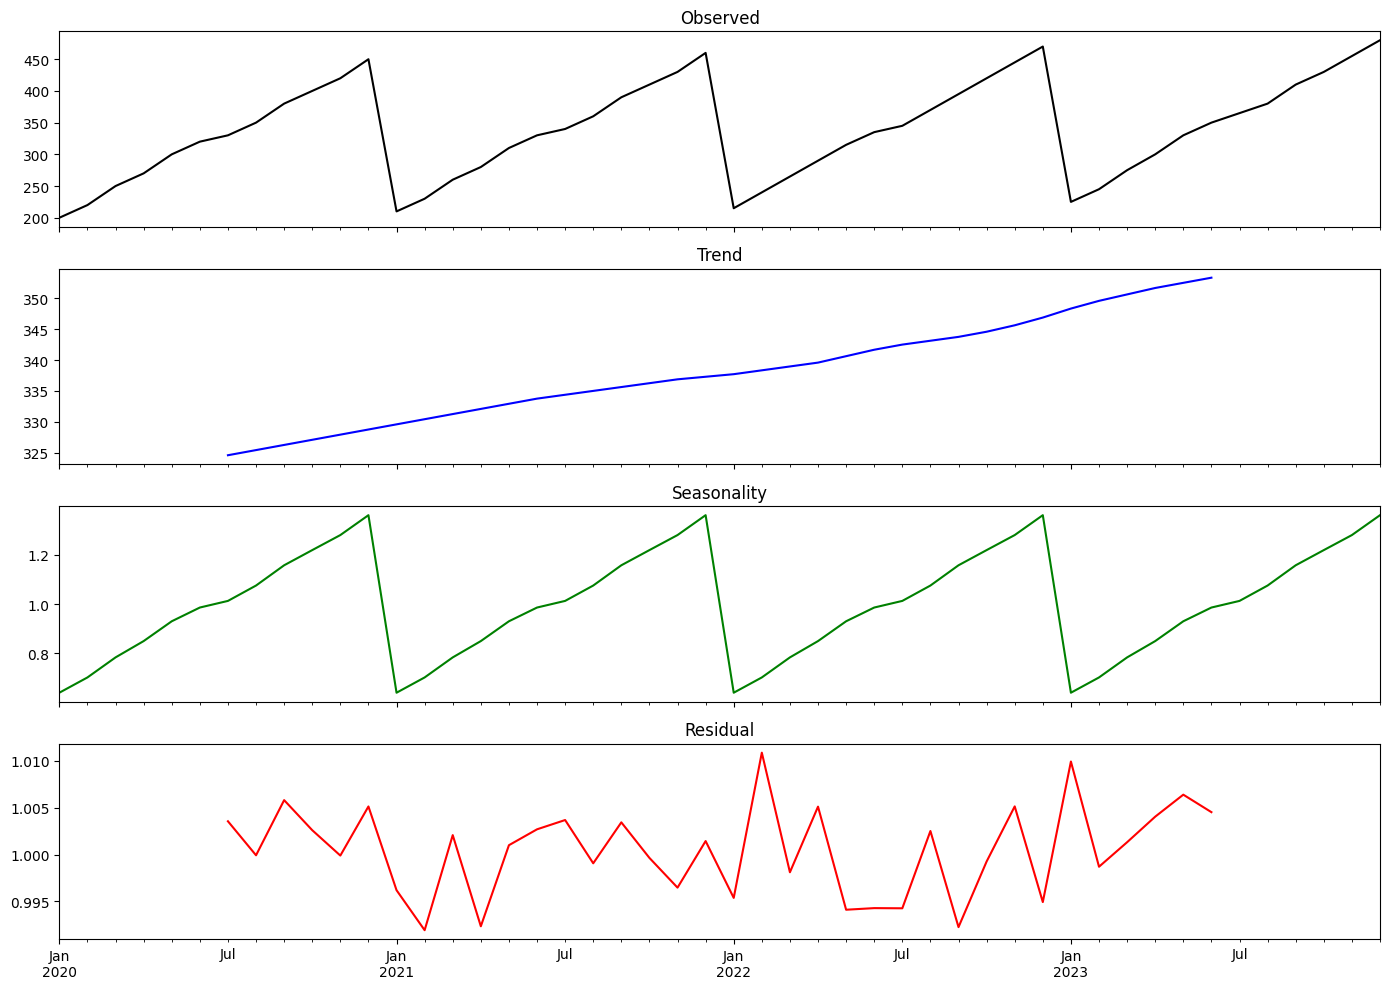

In [4]:
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)

result.observed.plot(ax=axes[0], color='black', title='Observed')
result.trend.plot(ax=axes[1], color='blue', title='Trend')
result.seasonal.plot(ax=axes[2], color='green', title='Seasonality')
result.resid.plot(ax=axes[3], color='red', title='Residual')

plt.tight_layout()
plt.show()
